To round out this project, we attempt to use our model for a real world application: fraud detection.

Method:
1) Take our test dataset and multiply some prices by a certain number.
2) Predict price using our model.
3) Observe the factor needed to multiply actual by to get prediction.
4) Assign prices as fraudulent above/below a certain factor.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pgeocode
import joblib
import numpy as np
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score, PrecisionRecallDisplay, precision_recall_curve

In [2]:
# Import and encode data, import model.
sold = pd.read_csv("C:/Users/44756/Documents/Postgrad/DSA8030/Data/sold_treated.csv", dtype = {'brokered_by':'string', 'street':'string', 'zip_code':'string'}, parse_dates = ['prev_sold_date'])
nomi = pgeocode.Nominatim('us')
location_data = nomi.query_postal_code(sold['zip_code'].tolist())
sold['latzip'] = location_data['latitude'].values
sold['longzip'] = location_data['longitude'].values
sold_dummy = pd.get_dummies(sold['state']).astype('int')
sold = pd.concat([sold, sold_dummy], axis = 1)
sold['cityfreq'] = sold['city'].map(sold['city'].value_counts())
sold['streetfreq'] = sold['street'].map(sold['street'].value_counts())
sold['brokerfreq'] = sold['brokered_by'].map(sold['brokered_by'].value_counts())
sold['otherstate_xgb'] = sold['state'].isin(['Vermont', 'Indiana', 'North Dakota', 'New Mexico', 'New Hampshire', 'Minnesota', 'Maine', 'Delaware', 'Alabama', 'Wyoming']).astype('int')
sold_train, sold_test = train_test_split(sold, test_size=0.2, random_state=1)
model = joblib.load("C:/Users/44756/Documents/Postgrad/DSA8030/model_xgb.joblib")

In [3]:
sold_test.sample(frac = 0.1, random_state=1)

,brokered_by,price,street,city,state,zip_code,prev_sold_date,county,po_box,bed,...,Vermont,Virginia,Washington,West Virginia,Wisconsin,Wyoming,cityfreq,streetfreq,brokerfreq,otherstate_xgb
189039,46709.0,340000.0,185846.0,Shoshone,Idaho,83352,2021-12-23,Camas County,0,3.0,...,0,0,0,0,0,0,5,1,13,0
639442,76328.0,24900.0,1973827.0,Rockland,Idaho,83271,2022-04-13,Power County,0,3.0,...,0,0,0,0,0,0,77,1,10,0
749724,91422.0,649900.0,1570937.0,Cotati,California,94931,2022-04-15,Sonoma County,0,3.0,...,0,0,0,0,0,0,22,1,11,0
765984,95850.0,440000.0,1084873.0,Placerville,California,95667,2022-04-22,El Dorado County,0,3.0,...,0,0,0,0,0,0,213,1,1,0
648913,83523.0,519900.0,1551075.0,Gilbert,Arizona,85298,2022-03-14,Maricopa County,0,3.0,...,0,0,0,0,0,0,833,1,771,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426579,7319.0,235900.0,242054.0,Florida City,Florida,33034,2022-04-21,Miami-Dade County,0,3.0,...,0,0,0,0,0,0,41,1,95,0
409578,59734.0,200000.0,1109242.0,Jacksonville,Florida,32257,2022-04-08,Duval County,0,2.0,...,0,0,0,0,0,0,5769,1,2,0
670819,53016.0,361500.0,832238.0,Los Lunas,New Mexico,87031,2022-02-28,Valencia County,0,3.0,...,0,0,0,0,0,0,267,1,10134,1
598661,53203.0,350000.0,1544910.0,North Richland Hills,Texas,76180,2022-03-25,Tarrant County,0,3.0,...,0,0,0,0,0,0,311,1,195,0


In [15]:
# Add a new column with some "fradulent" prices. For these selected frauds, multiply price by a random number between 1.5 and 2.
sold_test['is_fraud'] = sold_test.index.isin(sold_test.sample(frac = 0.1, random_state=1).index.tolist()).astype('int')
sold_test['price_mult'] = np.where(sold_test['is_fraud'] == 1, sold_test['price']*(random.randrange(150,200)/100), sold_test['price'])

In [16]:
xgb_x = sold_test[['bed', 'bath', 'acre_lot', 'house_size', 'latzip', 'longzip', 'cityfreq', 'streetfreq', 'brokerfreq', 'precipitation', 'maxtemp', 'avgtemp', 'po_box', 'population', 'density', 'dhighway', 'dlairport', 'dmairport', 'dshore', 'nobusiness', 'totalincome', 'tax_returns','Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'District of Columbia', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maryland', 'Massachusetts', 'Michigan', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Jersey', 'New York', 'North Carolina', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'otherstate_xgb']]
xgb_y = sold_test['price']
xgb_pred = model.predict(xgb_x)
sold_test = sold_test.assign(pred = xgb_pred)

In [17]:
sold_test['factor'] = sold_test['price_mult'] / sold_test['pred']

In [18]:
# pd.set_option('display.max_rows', 10000)
# pd.set_option('display.max_columns', None)
# display(sold_test.sort_values(by = 'factor', ascending = False).head(10000)[sold_test['factor'] > 1.5][['price', 'price_mult', 'is_fraud', 'pred', 'factor']])
# pd.reset_option('display.max_columns')
# pd.reset_option('display.max_rows')

In [19]:
sold_test['fraud_pred_15_2'] = ((sold_test['factor'] > 1.5) & (sold_test['factor'] < 2)).astype('int')
sold_test['fraud_pred_15_3'] = ((sold_test['factor'] > 1.5) & (sold_test['factor'] < 3)).astype('int')
sold_test['fraud_pred_15'] = (sold_test['factor'] > 1.5).astype('int')
sold_test['fraud_pred_14'] = (sold_test['factor'] > 1.4).astype('int')
sold_test['fraud_pred_13'] = (sold_test['factor'] > 1.3).astype('int')
sold_test['fraud_pred_12'] = (sold_test['factor'] > 1.2).astype('int')
sold_test['fraud_pred_11'] = (sold_test['factor'] > 1.1).astype('int')

In [20]:
sold_test

,brokered_by,price,street,city,state,zip_code,prev_sold_date,county,po_box,bed,...,price_mult,pred,factor,fraud_pred_15_2,fraud_pred_15_3,fraud_pred_15,fraud_pred_14,fraud_pred_13,fraud_pred_12,fraud_pred_11
333387,69808.0,680000.0,522789.0,Baltimore,Maryland,21228,2022-03-04,Baltimore County,0,4.0,...,680000.0,6.177967e+05,1.100686,0,0,0,0,0,0,1
9568,107925.0,459900.0,1192069.0,Randolph,Massachusetts,02368,2021-10-21,Norfolk County,0,3.0,...,878409.0,5.290736e+05,1.660278,1,1,1,1,1,1,1
578915,22929.0,185000.0,300389.0,Tulsa,Oklahoma,74128,2022-03-08,Tulsa County,0,4.0,...,185000.0,1.809363e+05,1.022459,0,0,0,0,0,0,0
63776,59096.0,484950.0,463591.0,Moseley,Virginia,23120,2021-11-18,Chesterfield County,0,5.0,...,484950.0,6.419011e+05,0.755490,0,0,0,0,0,0,0
337369,10457.0,330000.0,1620045.0,Aberdeen,Maryland,21001,2022-04-20,Harford County,0,3.0,...,630300.0,2.401488e+05,2.624622,0,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
429633,28939.0,1320000.0,1487562.0,Miami Beach,Florida,33141,2022-02-15,Miami-Dade County,0,3.0,...,1320000.0,1.459281e+06,0.904555,0,0,0,0,0,0,0
40945,4966.0,365000.0,522115.0,Elkton,Maryland,21921,2021-11-30,Cecil County,0,4.0,...,365000.0,3.195808e+05,1.142121,0,0,0,0,0,0,1
226864,47547.0,749000.0,258224.0,Santa Clara,California,95050,2021-11-16,Santa Clara County,0,2.0,...,749000.0,1.090119e+06,0.687081,0,0,0,0,0,0,0
168515,33968.0,225000.0,303149.0,Lewisville,Texas,75067,2021-11-18,Dallas County,0,2.0,...,429750.0,2.159523e+05,1.990023,1,1,1,1,1,1,1


In [21]:
def evaluate(col):
    print(ConfusionMatrixDisplay.from_predictions(sold_test['is_fraud'], sold_test[col], normalize='true'))
    print(classification_report(sold_test['is_fraud'], sold_test[col]))
# Note that in binary classification, recall of the positive class is also known as “sensitivity”; recall of the negative class is “specificity”.
# Sensitivity: Positives
# Specificity: Negatives

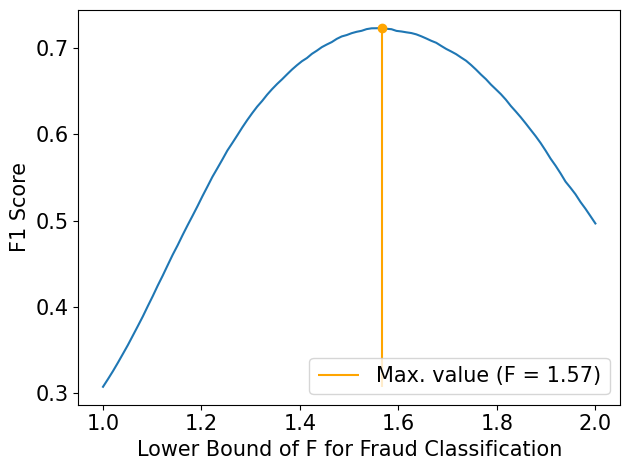

In [40]:
num = 100
vector = np.linspace(1,2,num)
scores = []
for n in vector:
    scores.append(classification_report(sold_test['is_fraud'], (sold_test['factor'] > n).astype('int'), output_dict=True)['1']['f1-score'])
plt.plot(vector, scores, zorder = 0)
plt.vlines(x=vector[np.where(scores == np.max(scores))], ymin = min(scores), ymax = max(scores), colors='orange', label = 'Max. value (F = 1.57)')
plt.scatter(vector[np.where(scores == np.max(scores))],max(scores), color = 'orange', zorder = 1)
plt.xlabel('Lower Bound of F for Fraud Classification', fontsize = '15')
plt.ylabel('F1 Score', fontsize = '15')
plt.legend(fontsize = '15')
plt.tick_params(axis = 'both', labelsize = '15')
plt.tight_layout()
plt.savefig('C:/Users/44756/Documents/Postgrad/DSA8030/fraud_f1.pdf')
plt.show()

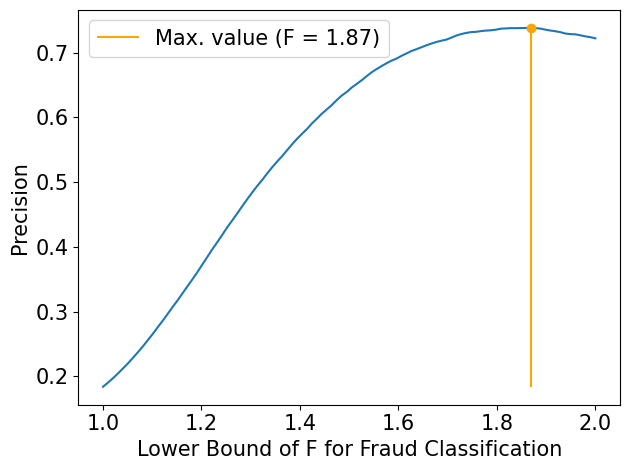

In [43]:
num = 100
vector = np.linspace(1,2,num)
scores = []
for n in vector:
    scores.append(classification_report(sold_test['is_fraud'], (sold_test['factor'] > n).astype('int'), output_dict=True)['1']['precision'])
plt.plot(vector, scores, zorder = 0)
plt.vlines(x=vector[np.where(scores == np.max(scores))], ymin = min(scores), ymax = max(scores), colors='orange', label = 'Max. value (F = 1.87)')
plt.scatter(vector[np.where(scores == np.max(scores))],max(scores), color = 'orange', zorder = 1)
plt.xlabel('Lower Bound of F for Fraud Classification', fontsize = '15')
plt.ylabel('Precision', fontsize = '15')
plt.legend(fontsize = '15')
plt.tick_params(axis = 'both', labelsize = '15')
plt.tight_layout()
plt.savefig('C:/Users/44756/Documents/Postgrad/DSA8030/fraud_precision.pdf')
plt.show()

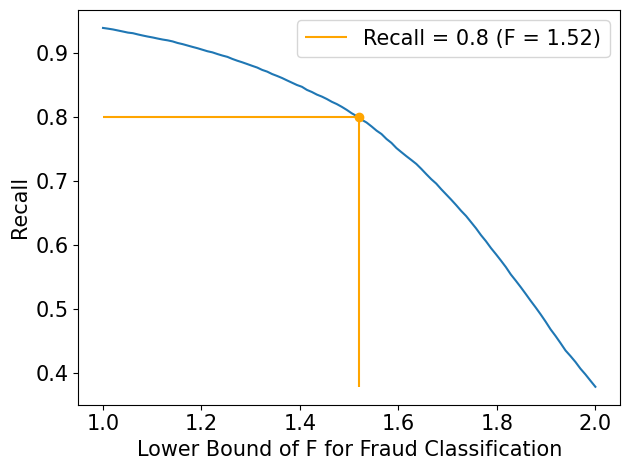

In [33]:
num = 100
vector = np.linspace(1,2,num)
scores = []
for n in vector:
    scores.append(classification_report(sold_test['is_fraud'], (sold_test['factor'] > n).astype('int'), output_dict=True)['1']['recall'])
plt.plot(vector, scores, zorder = 0)
plt.hlines(y = 0.8, xmin = 1, xmax = 1.52, colors = 'orange', label = 'Recall = 0.8 (F = 1.52)', zorder = 1)
plt.vlines(x=1.52, ymin = min(scores), ymax = 0.8, colors = 'orange', zorder = 1)
plt.scatter(1.52,0.8, color = 'orange', zorder = 1)
plt.xlabel('Lower Bound of F for Fraud Classification', fontsize = '15')
plt.ylabel('Recall', fontsize = '15')
plt.legend(fontsize = '15')
plt.tick_params(axis = 'both', labelsize = '15')
plt.tight_layout()
plt.savefig('C:/Users/44756/Documents/Postgrad/DSA8030/fraud_recall.pdf')
plt.show()

In [ ]:
print(classification_report(sold_test['is_fraud'], (sold_test['factor'] > 1.484848).astype('int')))
prec

              precision    recall  f1-score   support

           0       0.97      0.95      0.96    144922
           1       0.61      0.73      0.66     16102

    accuracy                           0.93    161024
   macro avg       0.79      0.84      0.81    161024
weighted avg       0.93      0.93      0.93    161024



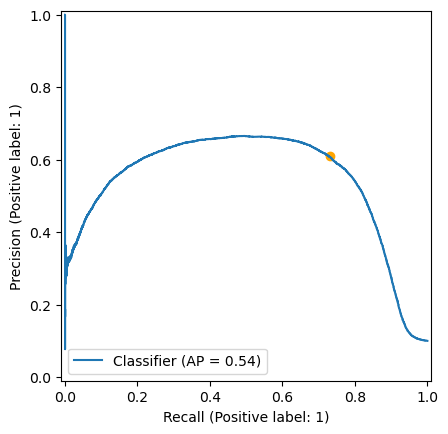

In [78]:
num = 100
vector = np.linspace(1,2,num)
prec_values = []
rec_values = []
for n in vector:
    report = classification_report(sold_test['is_fraud'], (sold_test['factor'] > n).astype('int'), output_dict=True)
    prec_values.append(report['1']['precision'])
    rec_values.append(report['1']['recall'])
PrecisionRecallDisplay.from_predictions(sold_test['is_fraud'], sold_test['factor'])
plt.scatter([0.73],[0.61], color = 'orange')
plt.show()


              precision    recall  f1-score   support

           0       0.96      0.96      0.96    144922
           1       0.61      0.61      0.61     16102

    accuracy                           0.92    161024
   macro avg       0.78      0.78      0.78    161024
weighted avg       0.92      0.92      0.92    161024



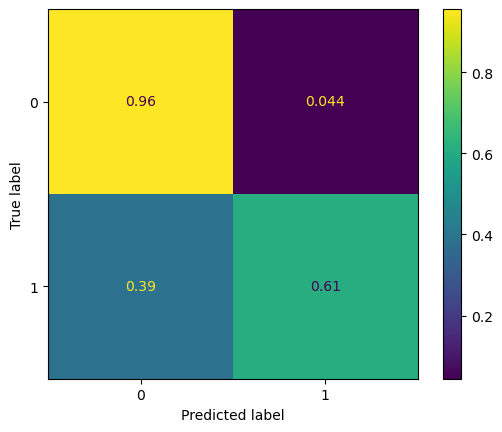

In [ ]:
evaluate('fraud_pred_15_3')

# f1 score plot
# precision/recall curve

              precision    recall  f1-score   support

           0       0.94      0.97      0.95    144922
           1       0.57      0.40      0.47     16102

    accuracy                           0.91    161024
   macro avg       0.75      0.68      0.71    161024
weighted avg       0.90      0.91      0.90    161024



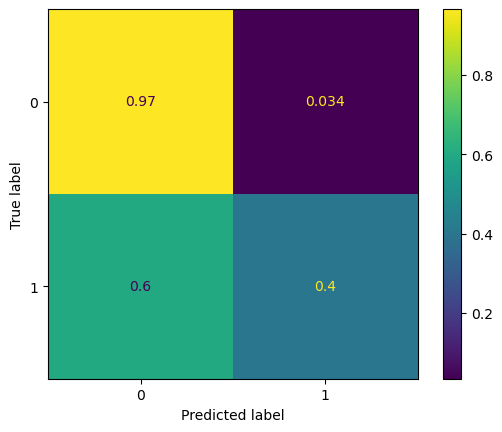

In [13]:
evaluate('fraud_pred_15_2')

              precision    recall  f1-score   support

           0       0.98      0.95      0.96    144922
           1       0.65      0.82      0.73     16102

    accuracy                           0.94    161024
   macro avg       0.81      0.89      0.85    161024
weighted avg       0.95      0.94      0.94    161024



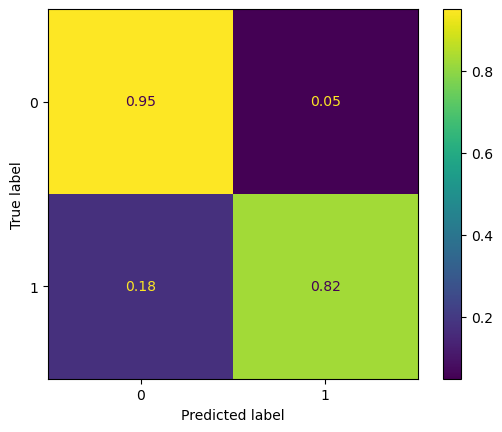

In [14]:
evaluate('fraud_pred_15')

              precision    recall  f1-score   support

           0       0.98      0.93      0.96    144922
           1       0.57      0.86      0.69     16102

    accuracy                           0.92    161024
   macro avg       0.78      0.89      0.82    161024
weighted avg       0.94      0.92      0.93    161024



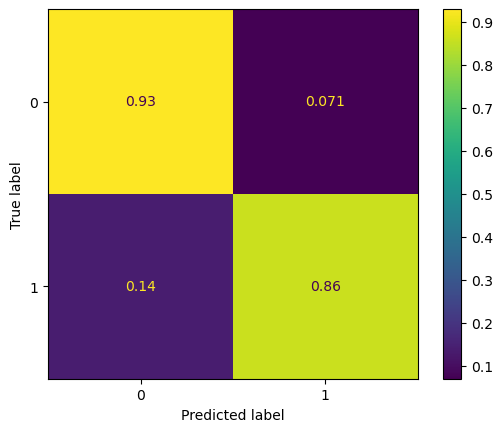

In [15]:
evaluate('fraud_pred_14')

              precision    recall  f1-score   support

           0       0.99      0.89      0.94    144922
           1       0.48      0.89      0.63     16102

    accuracy                           0.89    161024
   macro avg       0.73      0.89      0.78    161024
weighted avg       0.94      0.89      0.91    161024



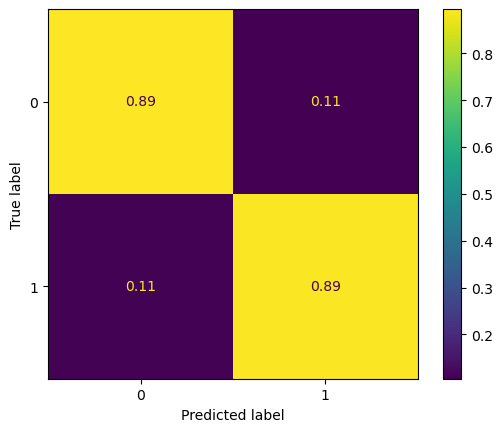

In [17]:
evaluate('fraud_pred_13')

              precision    recall  f1-score   support

           0       0.99      0.83      0.90    144922
           1       0.37      0.91      0.53     16102

    accuracy                           0.84    161024
   macro avg       0.68      0.87      0.72    161024
weighted avg       0.93      0.84      0.86    161024



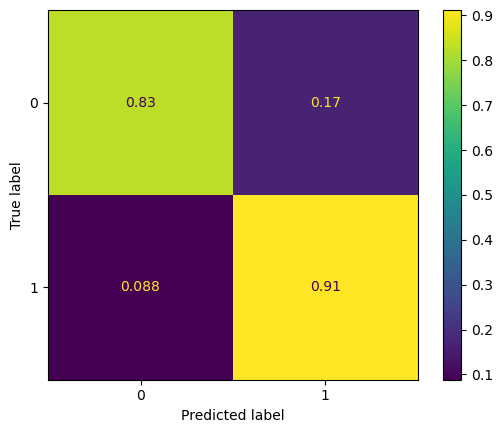

In [18]:
evaluate('fraud_pred_12')

              precision    recall  f1-score   support

           0       0.99      0.71      0.83    144922
           1       0.27      0.93      0.41     16102

    accuracy                           0.74    161024
   macro avg       0.63      0.82      0.62    161024
weighted avg       0.92      0.74      0.79    161024



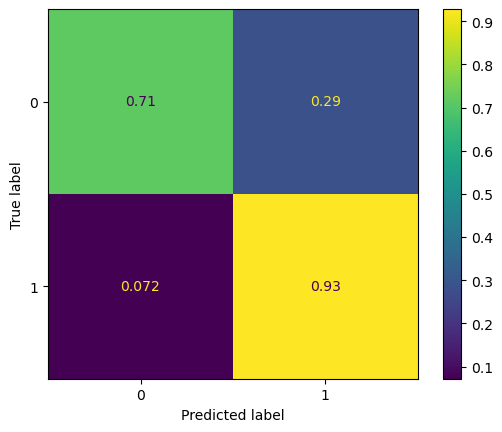

In [19]:
evaluate('fraud_pred_11')